# 03 - Análisis Exploratorio de Datos

En este notebook se realiza el análisis exploratorio del dataset limpio de usuarios de una plataforma de streaming.

El objetivo es analizar la distribución de las variables principales, explorar relaciones entre variables y obtener hallazgos útiles para comunicar en el informe y en la aplicación interactiva.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/PI_Mineria_Datos_1/notebooks

/content/drive/MyDrive/PI_Mineria_Datos_1/notebooks


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "../data/processed/streaming_users_clean.csv",
    parse_dates=["last_login_date"]
)

df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,1
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


In [5]:
df.shape

(8000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   8000 non-null   int64         
 1   age                       8000 non-null   int64         
 2   subscription_plan         8000 non-null   object        
 3   monthly_watch_time_mins   8000 non-null   float64       
 4   country                   8000 non-null   object        
 5   favorite_genre            7763 non-null   object        
 6   last_login_date           7606 non-null   datetime64[ns]
 7   customer_support_tickets  8000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 500.1+ KB


El análisis exploratorio se realiza sobre el dataset limpio guardado en `data/processed`.

En esta etapa no se modifica el dataset. El objetivo es explorar distribuciones, patrones y relaciones entre variables para obtener conclusiones iniciales.

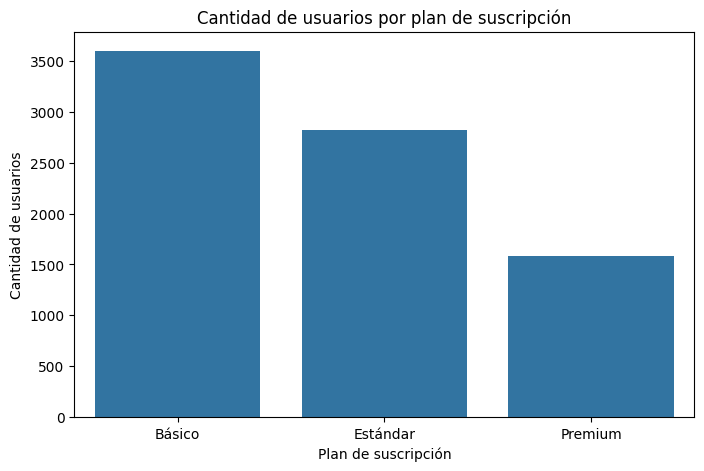

In [8]:
# Visualización univariada: cantidad de usuarios por plan de suscripción

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="subscription_plan",
    order=df["subscription_plan"].value_counts().index
)

plt.title("Cantidad de usuarios por plan de suscripción")
plt.xlabel("Plan de suscripción")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.show()

### Distribución de usuarios por plan de suscripción

El gráfico muestra la cantidad de usuarios registrados en cada plan de suscripción.

Esta visualización permite identificar qué plan concentra mayor cantidad de usuarios y si la distribución entre planes es equilibrada o presenta diferencias importantes.

A partir de este análisis se puede observar qué tipo de plan tiene mayor presencia dentro de la base de usuarios.

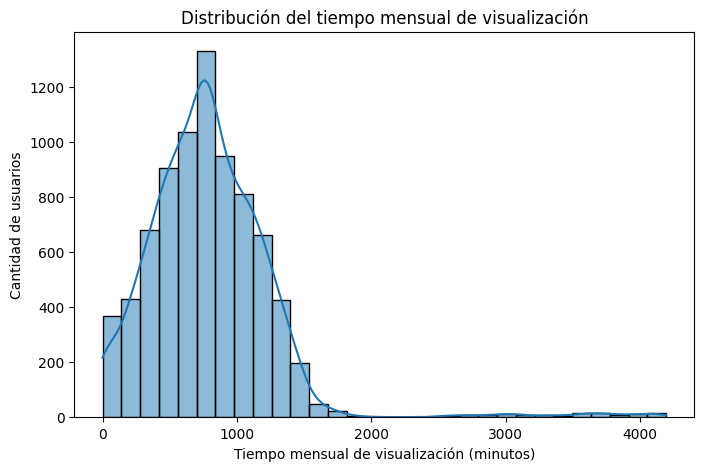

In [9]:
# Visualización univariada: distribución del tiempo mensual de visualización

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="monthly_watch_time_mins",
    bins=30,
    kde=True
)

plt.title("Distribución del tiempo mensual de visualización")
plt.xlabel("Tiempo mensual de visualización (minutos)")
plt.ylabel("Cantidad de usuarios")
plt.show()

### Distribución del tiempo mensual de visualización

El histograma muestra que la mayor concentración de usuarios se encuentra aproximadamente alrededor de los 800 minutos mensuales de visualización.

Además, la distribución presenta una cola extendida hacia la derecha, lo que indica que existe un grupo menor de usuarios con tiempos de visualización mucho más altos que la mayoría.

Esto sugiere una distribución asimétrica positiva: la mayoría de los usuarios tiene un consumo moderado, mientras que pocos usuarios concentran valores elevados de visualización mensual.

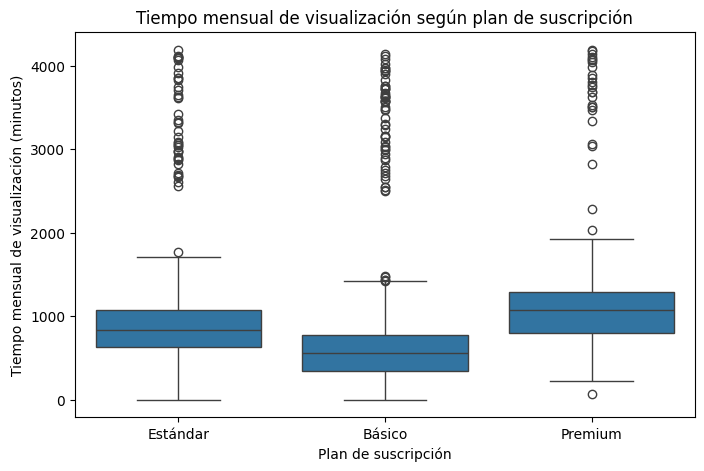

In [10]:
# Visualización bivariada: tiempo de visualización mensual según plan de suscripción

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo mensual de visualización según plan de suscripción")
plt.xlabel("Plan de suscripción")
plt.ylabel("Tiempo mensual de visualización (minutos)")
plt.show()

### Tiempo mensual de visualización según plan de suscripción

El boxplot muestra diferencias en el tiempo mensual de visualización según el plan de suscripción.

La línea negra dentro de cada caja representa la mediana. Se observa que el plan Premium presenta una mediana más alta que los planes Estándar y Básico, lo que indica que sus usuarios tienden a mirar más minutos mensuales.

El plan Básico muestra la mediana más baja, por lo que sus usuarios parecen tener menor consumo mensual en comparación con los otros planes.

También se observan puntos por encima de los bigotes en los tres planes. Estos puntos representan valores atípicos, es decir, usuarios con tiempos de visualización mucho más altos que la mayoría. Como los valores imposibles ya fueron tratados en la limpieza, estos casos pueden interpretarse como usuarios de consumo intensivo.

In [11]:
# Calculamos el promedio de tiempo mensual de visualización por país

promedio_pais = (
    df.groupby("country")["monthly_watch_time_mins"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

promedio_pais

,country,monthly_watch_time_mins
0,Brasil,807.411505
1,Perú,805.088713
2,Argentina,803.048959
3,Uruguay,789.754331
4,México,785.544983
5,Colombia,782.402715
6,Chile,781.145619


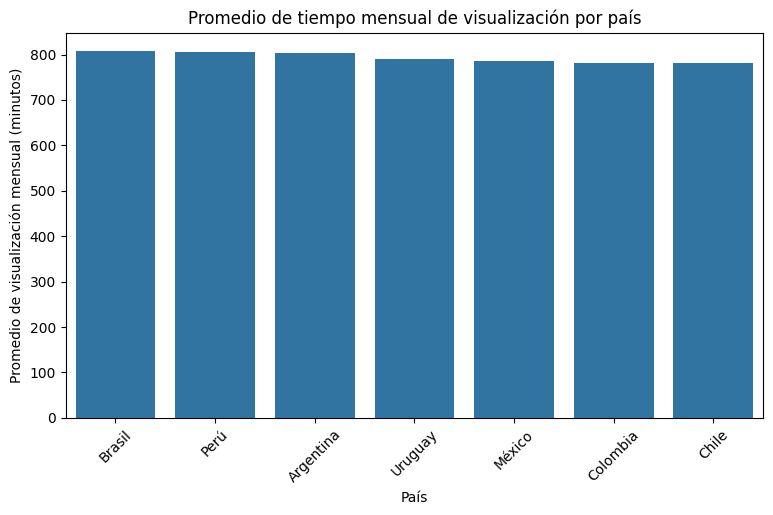

In [12]:
# Visualización bivariada: promedio de visualización mensual por país

plt.figure(figsize=(9, 5))

sns.barplot(
    data=promedio_pais,
    x="country",
    y="monthly_watch_time_mins"
)

plt.title("Promedio de tiempo mensual de visualización por país")
plt.xlabel("País")
plt.ylabel("Promedio de visualización mensual (minutos)")
plt.xticks(rotation=45)
plt.show()

### Promedio de tiempo mensual de visualización por país

El gráfico muestra el promedio de minutos mensuales de visualización para cada país.

Se observa que los promedios son bastante similares entre países. Brasil presenta el promedio más alto, con aproximadamente 807 minutos mensuales, mientras que Chile presenta el promedio más bajo, con aproximadamente 781 minutos.

La diferencia entre el país con mayor y menor promedio es reducida, por lo que no se observan contrastes fuertes en el consumo promedio por país. Esto sugiere que el tiempo mensual de visualización es relativamente parejo entre las regiones analizadas.

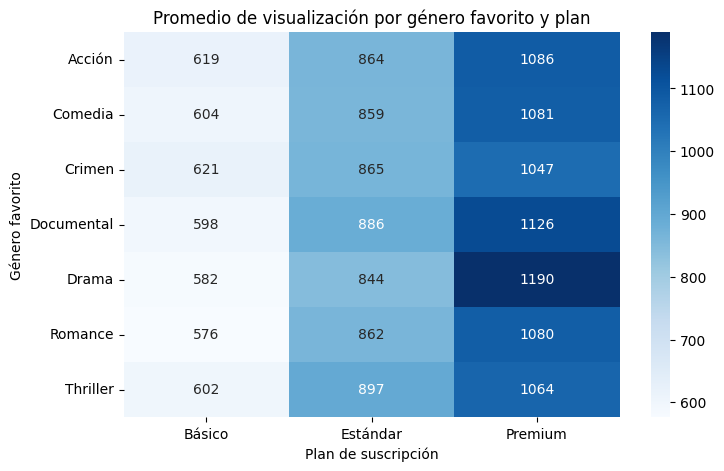

In [17]:
# Visualización multivariada:
# Promedio de visualización mensual según género favorito y plan de suscripción

tabla_genero_plan = df.pivot_table(
    values="monthly_watch_time_mins",
    index="favorite_genre",
    columns="subscription_plan",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_genero_plan,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Promedio de visualización por género favorito y plan")
plt.xlabel("Plan de suscripción")
plt.ylabel("Género favorito")
plt.show()

### Promedio de visualización por género favorito y plan

El heatmap muestra el promedio de minutos mensuales de visualización según el género favorito y el plan de suscripción.

Se observa que, en todos los géneros, los usuarios del plan Premium presentan los promedios de visualización más altos. En cambio, los usuarios del plan Básico muestran los valores promedio más bajos.

El mayor promedio se observa en usuarios del plan Premium cuyo género favorito es Drama, con aproximadamente 1190 minutos mensuales. También se destacan valores altos en Premium para Documental y Acción.

En los planes Básico y Estándar, las diferencias entre géneros son menores. Esto sugiere que el tipo de plan parece estar más asociado al nivel de consumo que el género favorito.

Esta visualización es multivariada porque permite analizar simultáneamente el género favorito, el plan de suscripción y el promedio de tiempo mensual de visualización.

## Conclusiones del análisis exploratorio

A partir del análisis exploratorio se observaron distintos patrones relacionados con el comportamiento de visualización de los usuarios de la plataforma.

En primer lugar, la distribución por plan de suscripción permitió identificar cómo se reparte la base de usuarios entre los planes Básico, Estándar y Premium.

Luego, el análisis del tiempo mensual de visualización mostró que la mayoría de los usuarios se concentra en valores moderados de consumo, con una cola extendida hacia la derecha. Esto indica que existe un grupo menor de usuarios con tiempos de visualización mucho más altos que la mayoría.

Al comparar el tiempo mensual de visualización según el plan de suscripción, se observó que el plan Premium presenta valores centrales más altos, mientras que el plan Básico muestra menores niveles de consumo. Esto sugiere que el tipo de plan podría estar asociado con diferencias en el comportamiento de visualización.

En el análisis por país, los promedios de visualización mensual resultaron bastante similares entre las regiones analizadas. Brasil presentó el promedio más alto y Chile el más bajo, aunque la diferencia entre ambos fue reducida.

Finalmente, el heatmap permitió analizar conjuntamente el género favorito, el plan de suscripción y el promedio de visualización. Se observó que los usuarios Premium presentan los valores más altos en casi todos los géneros, mientras que las diferencias entre géneros dentro de un mismo plan son menores.

En conclusión, el EDA se centró principalmente en estudiar el tiempo mensual de visualización. Los resultados sugieren que el plan de suscripción muestra diferencias más claras en el consumo que otras variables como el país o el género favorito.